In [1]:
# %%
# Cell 1 - Imports and Setup

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Paths
ARTIFACT_DIR = Path("artifacts")
DATA_DIR = Path("../data")

# Model config
MODEL_NAME = "roberta-base"
MAX_LEN = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
label_names = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

print("torch", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", DEVICE)


c:\Users\Yasna\Desktop\CMD Project 1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.9.1+cu128
cuda available: True
device: cuda


In [2]:

# %%
# Cell 2 - Load Model and Data

print("="*60)
print("LOADING MODEL AND TEST DATA")
print("="*60)

# Load trained model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=len(label_names)
)
model.load_state_dict(torch.load(ARTIFACT_DIR / "primary_v3_fold0.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load test data
df_full = pd.read_csv(DATA_DIR / "processed_text.csv", keep_default_na=False)
n_train = 127656
df_test = df_full.iloc[n_train:].reset_index(drop=True)
y_test = df_test[label_names].values

print(f"✅ Model loaded")
print(f"✅ Test set: {len(df_test)} samples")

# Load test predictions
test_preds = np.load(ARTIFACT_DIR / "test_predictions_final.npy")
print(f"✅ Predictions loaded: {test_preds.shape}")


LOADING MODEL AND TEST DATA


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded
✅ Test set: 31915 samples
✅ Predictions loaded: (31915, 6)


In [3]:

# %%
# Cell 3 - Helper Functions

def predict_text(text):
    """Get predictions for a single text"""
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )
    
    input_ids = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)
    
    with torch.no_grad():
        logits = model(input_ids, attention_mask=attention_mask).logits
        probs = torch.sigmoid(logits)[0].cpu().numpy()
    
    return probs

def predict_batch(texts, batch_size=32):
    """Get predictions for multiple texts"""
    all_probs = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch_texts = texts[i:i+batch_size]
        
        encoding = tokenizer(
            batch_texts,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        
        input_ids = encoding["input_ids"].to(DEVICE)
        attention_mask = encoding["attention_mask"].to(DEVICE)
        
        with torch.no_grad():
            logits = model(input_ids, attention_mask=attention_mask).logits
            probs = torch.sigmoid(logits).cpu().numpy()
        
        all_probs.append(probs)
    
    return np.vstack(all_probs)

print("✅ Helper functions defined")


✅ Helper functions defined


In [4]:

# %%
# Cell 4 - Identity Term Bias Test

print("="*60)
print("BIAS TEST 1: Identity Term Bias")
print("="*60)

# Define identity terms to test
identity_groups = {
    'race': ['Black', 'White', 'Asian', 'Hispanic', 'Latino', 'African American'],
    'religion': ['Christian', 'Muslim', 'Jewish', 'Hindu', 'Buddhist', 'atheist'],
    'gender': ['man', 'woman', 'male', 'female', 'transgender', 'non-binary'],
    'sexuality': ['gay', 'lesbian', 'bisexual', 'straight', 'heterosexual', 'queer'],
    'nationality': ['American', 'Mexican', 'Chinese', 'Indian', 'British', 'French']
}

# Test templates (neutral sentences)
neutral_templates = [
    "I am {identity}.",
    "My friend is {identity}.",
    "Being {identity} is part of who I am.",
    "{identity} people deserve respect.",
    "I identify as {identity}.",
]

# Generate test cases
bias_test_cases = []

for category, identities in identity_groups.items():
    for identity in identities:
        for template in neutral_templates:
            text = template.format(identity=identity)
            bias_test_cases.append({
                'text': text,
                'category': category,
                'identity': identity,
                'template': template
            })

print(f"Generated {len(bias_test_cases)} neutral test cases")

# Get predictions
bias_test_df = pd.DataFrame(bias_test_cases)
bias_test_texts = bias_test_df['text'].tolist()

print("\nPredicting...")
bias_predictions = predict_batch(bias_test_texts, batch_size=32)

# Add predictions to dataframe
for i, label in enumerate(label_names):
    bias_test_df[f'{label}_score'] = bias_predictions[:, i]

# Flag as toxic if any label > 0.5
bias_test_df['flagged_as_toxic'] = (bias_predictions.max(axis=1) > 0.5)
bias_test_df['max_score'] = bias_predictions.max(axis=1)
bias_test_df['flagged_label'] = [label_names[i] for i in bias_predictions.argmax(axis=1)]

# Analysis
print("\n" + "="*60)
print("RESULTS: Identity Term Bias")
print("="*60)

# Overall false positive rate
fp_rate = bias_test_df['flagged_as_toxic'].mean()
print(f"\nOverall false positive rate: {fp_rate:.2%}")
print(f"({bias_test_df['flagged_as_toxic'].sum()} out of {len(bias_test_df)} neutral statements flagged)")

# By category
print("\nFalse positive rate by identity category:")
for category in identity_groups.keys():
    cat_df = bias_test_df[bias_test_df['category'] == category]
    cat_fp_rate = cat_df['flagged_as_toxic'].mean()
    n_flagged = cat_df['flagged_as_toxic'].sum()
    print(f"  {category:15s}: {cat_fp_rate:5.2%} ({n_flagged}/{len(cat_df)} flagged)")

# By specific identity
print("\nTop 10 identities with highest false positive rates:")
identity_fp = bias_test_df.groupby('identity').agg({
    'flagged_as_toxic': ['mean', 'sum', 'count']
}).round(3)
identity_fp.columns = ['fp_rate', 'n_flagged', 'n_total']
identity_fp = identity_fp.sort_values('fp_rate', ascending=False)
print(identity_fp.head(10))

# Save results
bias_test_df.to_csv(ARTIFACT_DIR / "bias_test_identity_terms.csv", index=False)
print(f"\n✅ Saved detailed results to: {ARTIFACT_DIR / 'bias_test_identity_terms.csv'}")


BIAS TEST 1: Identity Term Bias
Generated 150 neutral test cases

Predicting...


Predicting: 100%|██████████| 5/5 [00:02<00:00,  1.85it/s]


RESULTS: Identity Term Bias

Overall false positive rate: 4.00%
(6 out of 150 neutral statements flagged)

False positive rate by identity category:
  race           : 0.00% (0/30 flagged)
  religion       : 0.00% (0/30 flagged)
  gender         : 0.00% (0/30 flagged)
  sexuality      : 20.00% (6/30 flagged)
  nationality    : 0.00% (0/30 flagged)

Top 10 identities with highest false positive rates:
                  fp_rate  n_flagged  n_total
identity                                     
lesbian               0.4          2        5
gay                   0.4          2        5
heterosexual          0.2          1        5
bisexual              0.2          1        5
African American      0.0          0        5
American              0.0          0        5
transgender           0.0          0        5
straight              0.0          0        5
queer                 0.0          0        5
non-binary            0.0          0        5

✅ Saved detailed results to: artifacts\bia

In [5]:

# %%
# Cell 5 - False Positive Analysis

print("="*60)
print("BIAS TEST 2: False Positive Analysis")
print("="*60)

# Get thresholds from training
final_thresholds = np.array([0.3924, 0.3274, 0.3738, 0.2995, 0.3738, 0.3181])

# Binary predictions
test_preds_binary = (test_preds >= final_thresholds).astype(int)

# Find false positives for each label
false_positives = {}

for i, label in enumerate(label_names):
    # False positives: predicted 1, actual 0
    fp_mask = (test_preds_binary[:, i] == 1) & (y_test[:, i] == 0)
    fp_indices = np.where(fp_mask)[0]
    
    # Get texts and scores
    fp_texts = df_test.iloc[fp_indices]['comment_text'].tolist()
    fp_scores = test_preds[fp_indices, i]
    
    false_positives[label] = {
        'count': len(fp_indices),
        'rate': len(fp_indices) / (y_test[:, i] == 0).sum(),
        'texts': fp_texts[:20],  # Store top 20 for analysis
        'scores': fp_scores[:20]
    }
    
    print(f"\n{label:15s}:")
    print(f"  False positives: {len(fp_indices)} ({false_positives[label]['rate']:.2%} of negatives)")
    print(f"  Sample false positives:")
    for j, (text, score) in enumerate(zip(fp_texts[:3], fp_scores[:3]), 1):
        print(f"    {j}. [{score:.3f}] {text[:80]}...")


BIAS TEST 2: False Positive Analysis

toxic          :
  False positives: 495 (1.71% of negatives)
  Sample false positives:
    1. [0.554] Listen here moron, you completely violate wikipedia regulations both on your use...
    2. [0.562] "

Erroneous comment stricken. Still, don't delete comments outright just becaus...
    3. [0.489] What a hypocrite !  is blatantly biased, accuses everyone of sockpuppetry, ignor...

severe_toxic   :
  False positives: 286 (0.90% of negatives)
  Sample false positives:
    1. [0.422] ronaldo is a fucking bitch...
    2. [0.359] Shit nigga WTF CHILL DEM BITCHES DOG!!!!...
    3. [0.426] stfu ==

WHY DONT U STFU AND GET A LIFE! IF YOU LIKE TO PLAY THAT GAY GAME SO MU...

obscene        :
  False positives: 344 (1.14% of negatives)
  Sample false positives:
    1. [0.595] Oi!!

Please do not remove me abusing other wikipedians dickhead!

Oi!!

Please ...
    2. [0.530] "

You are a half-turk, half-arab with no roots who can't even speak or write Pe...
 

In [6]:

# %%
# Cell 6 - Contextual Bias Test

print("="*60)
print("BIAS TEST 3: Context Sensitivity")
print("="*60)

# Test cases: Similar words in different contexts
context_tests = [
    # Reclaimed slurs
    {'text': 'That was so gay (in a good way)', 'expected': 'NOT_TOXIC', 'note': 'Positive usage'},
    {'text': 'Queer liberation now!', 'expected': 'NOT_TOXIC', 'note': 'Activist/reclaimed'},
    
    # Educational/discussion
    {'text': 'The n-word has a complex history in America', 'expected': 'NOT_TOXIC', 'note': 'Educational context'},
    {'text': 'We need to discuss why slurs are harmful', 'expected': 'NOT_TOXIC', 'note': 'Meta-discussion'},
    
    # Slang/AAVE
    {'text': "That's sick bro!", 'expected': 'NOT_TOXIC', 'note': 'Slang (positive)'},
    {'text': 'This is lit af', 'expected': 'NOT_TOXIC', 'note': 'AAVE/slang'},
    
    # Passionate but not toxic
    {'text': 'I absolutely hate winter weather', 'expected': 'NOT_TOXIC', 'note': 'Strong opinion on weather'},
    {'text': 'This policy is terrible and needs to change', 'expected': 'NOT_TOXIC', 'note': 'Political criticism'},
    
    # Clear toxicity (control)
    {'text': 'You are a worthless piece of garbage', 'expected': 'TOXIC', 'note': 'Clear personal attack'},
    {'text': 'Kill yourself you loser', 'expected': 'TOXIC', 'note': 'Clear threat/insult'},
]

context_df = pd.DataFrame(context_tests)

# Get predictions
context_texts = context_df['text'].tolist()
context_preds = predict_batch(context_texts, batch_size=len(context_texts))

# Add predictions
context_df['max_score'] = context_preds.max(axis=1)
context_df['predicted_label'] = [label_names[i] for i in context_preds.argmax(axis=1)]
context_df['model_decision'] = ['TOXIC' if score > 0.5 else 'NOT_TOXIC' for score in context_preds.max(axis=1)]
context_df['correct'] = context_df['model_decision'] == context_df['expected']

# Display results
print("\nContext Sensitivity Results:")
print("="*60)

for idx, row in context_df.iterrows():
    status = "✅" if row['correct'] else "❌"
    print(f"\n{status} Test {idx+1}: {row['note']}")
    print(f"   Text: {row['text']}")
    print(f"   Expected: {row['expected']}")
    print(f"   Model: {row['model_decision']} ({row['predicted_label']}, {row['max_score']:.3f})")

# Summary
accuracy = context_df['correct'].mean()
print(f"\n{'='*60}")
print(f"Context sensitivity accuracy: {accuracy:.1%} ({context_df['correct'].sum()}/{len(context_df)})")

# Save results
context_df.to_csv(ARTIFACT_DIR / "bias_test_context_sensitivity.csv", index=False)
print(f"✅ Saved to: {ARTIFACT_DIR / 'bias_test_context_sensitivity.csv'}")


BIAS TEST 3: Context Sensitivity


Predicting: 100%|██████████| 1/1 [00:00<00:00,  3.69it/s]


Context Sensitivity Results:

❌ Test 1: Positive usage
   Text: That was so gay (in a good way)
   Expected: NOT_TOXIC
   Model: TOXIC (toxic, 0.551)

✅ Test 2: Activist/reclaimed
   Text: Queer liberation now!
   Expected: NOT_TOXIC
   Model: NOT_TOXIC (toxic, 0.180)

✅ Test 3: Educational context
   Text: The n-word has a complex history in America
   Expected: NOT_TOXIC
   Model: NOT_TOXIC (toxic, 0.143)

✅ Test 4: Meta-discussion
   Text: We need to discuss why slurs are harmful
   Expected: NOT_TOXIC
   Model: NOT_TOXIC (toxic, 0.097)

❌ Test 5: Slang (positive)
   Text: That's sick bro!
   Expected: NOT_TOXIC
   Model: TOXIC (toxic, 0.514)

✅ Test 6: AAVE/slang
   Text: This is lit af
   Expected: NOT_TOXIC
   Model: NOT_TOXIC (toxic, 0.137)

✅ Test 7: Strong opinion on weather
   Text: I absolutely hate winter weather
   Expected: NOT_TOXIC
   Model: NOT_TOXIC (toxic, 0.471)

✅ Test 8: Political criticism
   Text: This policy is terrible and needs to change
   Expected: NOT_TOX

In [7]:

# %%
# Cell 7 - Generate Bias Report

print("="*60)
print("GENERATING COMPREHENSIVE BIAS REPORT")
print("="*60)

# Create report
report = []

report.append("# Content Moderation Bias Testing Report\n")
report.append(f"Model: {MODEL_NAME}\n")
report.append(f"Test Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}\n")
report.append(f"Test Set Size: {len(df_test)} samples\n\n")

# Section 1: Identity Term Bias
report.append("## 1. Identity Term Bias\n\n")
report.append(f"**Overall False Positive Rate:** {fp_rate:.2%}\n\n")
report.append("Tested {len(bias_test_cases)} neutral statements containing identity terms.\n\n")
report.append("### Results by Category:\n\n")
for category in identity_groups.keys():
    cat_df = bias_test_df[bias_test_df['category'] == category]
    cat_fp_rate = cat_df['flagged_as_toxic'].mean()
    report.append(f"- **{category.title()}**: {cat_fp_rate:.2%} false positive rate\n")

report.append("\n### Highest Risk Identities:\n\n")
top_identities = identity_fp.head(5)
for identity, row in top_identities.iterrows():
    report.append(f"- **{identity}**: {row['fp_rate']:.2%} ({int(row['n_flagged'])}/{int(row['n_total'])} flagged)\n")

# Section 2: False Positive Analysis
report.append("\n## 2. False Positive Analysis\n\n")
report.append("Analysis of incorrectly flagged content:\n\n")
for label in label_names:
    report.append(f"- **{label.replace('_', ' ').title()}**: {false_positives[label]['count']} false positives ")
    report.append(f"({false_positives[label]['rate']:.2%} of true negatives)\n")

# Section 3: Context Sensitivity
report.append("\n## 3. Context Sensitivity\n\n")
report.append(f"**Accuracy:** {accuracy:.1%} ({context_df['correct'].sum()}/{len(context_df)} tests passed)\n\n")
report.append("The model was tested on:\n")
report.append("- Reclaimed slurs in positive contexts\n")
report.append("- Educational/meta-discussion of harmful language\n")
report.append("- AAVE and modern slang\n")
report.append("- Passionate but non-toxic criticism\n\n")

failed_tests = context_df[~context_df['correct']]
if len(failed_tests) > 0:
    report.append("### Failed Tests:\n\n")
    for idx, row in failed_tests.iterrows():
        report.append(f"- {row['note']}: Expected {row['expected']}, got {row['model_decision']}\n")
else:
    report.append("✅ All context sensitivity tests passed!\n")

# Section 4: Recommendations
report.append("\n## 4. Recommendations\n\n")

if fp_rate > 0.10:
    report.append("⚠️ **High identity bias detected** (>10% false positive rate on neutral identity mentions)\n")
    report.append("- Consider fine-tuning with balanced identity-term examples\n")
    report.append("- Implement identity-term whitelisting for neutral contexts\n\n")
elif fp_rate > 0.05:
    report.append("⚡ **Moderate identity bias** (5-10% false positive rate)\n")
    report.append("- Monitor for disproportionate impact on specific communities\n")
    report.append("- Consider threshold adjustments for identity_hate category\n\n")
else:
    report.append("✅ **Low identity bias** (<5% false positive rate)\n")
    report.append("- Current performance is acceptable\n")
    report.append("- Continue monitoring in production\n\n")

if accuracy < 0.7:
    report.append("⚠️ **Poor context sensitivity** (<70% accuracy)\n")
    report.append("- Model struggles with nuanced contexts\n")
    report.append("- Recommend additional training on contextual examples\n\n")
elif accuracy < 0.9:
    report.append("⚡ **Moderate context sensitivity** (70-90% accuracy)\n")
    report.append("- Some contextual understanding, but room for improvement\n\n")
else:
    report.append("✅ **Good context sensitivity** (>90% accuracy)\n\n")

# Save report
report_text = "".join(report)
report_path = ARTIFACT_DIR / "bias_testing_report.md"

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(report_text)
print("="*60)
print(f"✅ Report saved to: {report_path}")


GENERATING COMPREHENSIVE BIAS REPORT
# Content Moderation Bias Testing Report
Model: roberta-base
Test Date: 2025-12-28
Test Set Size: 31915 samples

## 1. Identity Term Bias

**Overall False Positive Rate:** 4.00%

Tested {len(bias_test_cases)} neutral statements containing identity terms.

### Results by Category:

- **Race**: 0.00% false positive rate
- **Religion**: 0.00% false positive rate
- **Gender**: 0.00% false positive rate
- **Sexuality**: 20.00% false positive rate
- **Nationality**: 0.00% false positive rate

### Highest Risk Identities:

- **lesbian**: 40.00% (2/5 flagged)
- **gay**: 40.00% (2/5 flagged)
- **heterosexual**: 20.00% (1/5 flagged)
- **bisexual**: 20.00% (1/5 flagged)
- **African American**: 0.00% (0/5 flagged)

## 2. False Positive Analysis

Analysis of incorrectly flagged content:

- **Toxic**: 495 false positives (1.71% of true negatives)
- **Severe Toxic**: 286 false positives (0.90% of true negatives)
- **Obscene**: 344 false positives (1.14% of true ne

Generating visualizations...
✅ Saved visualizations to: artifacts\bias_testing_visualizations.png


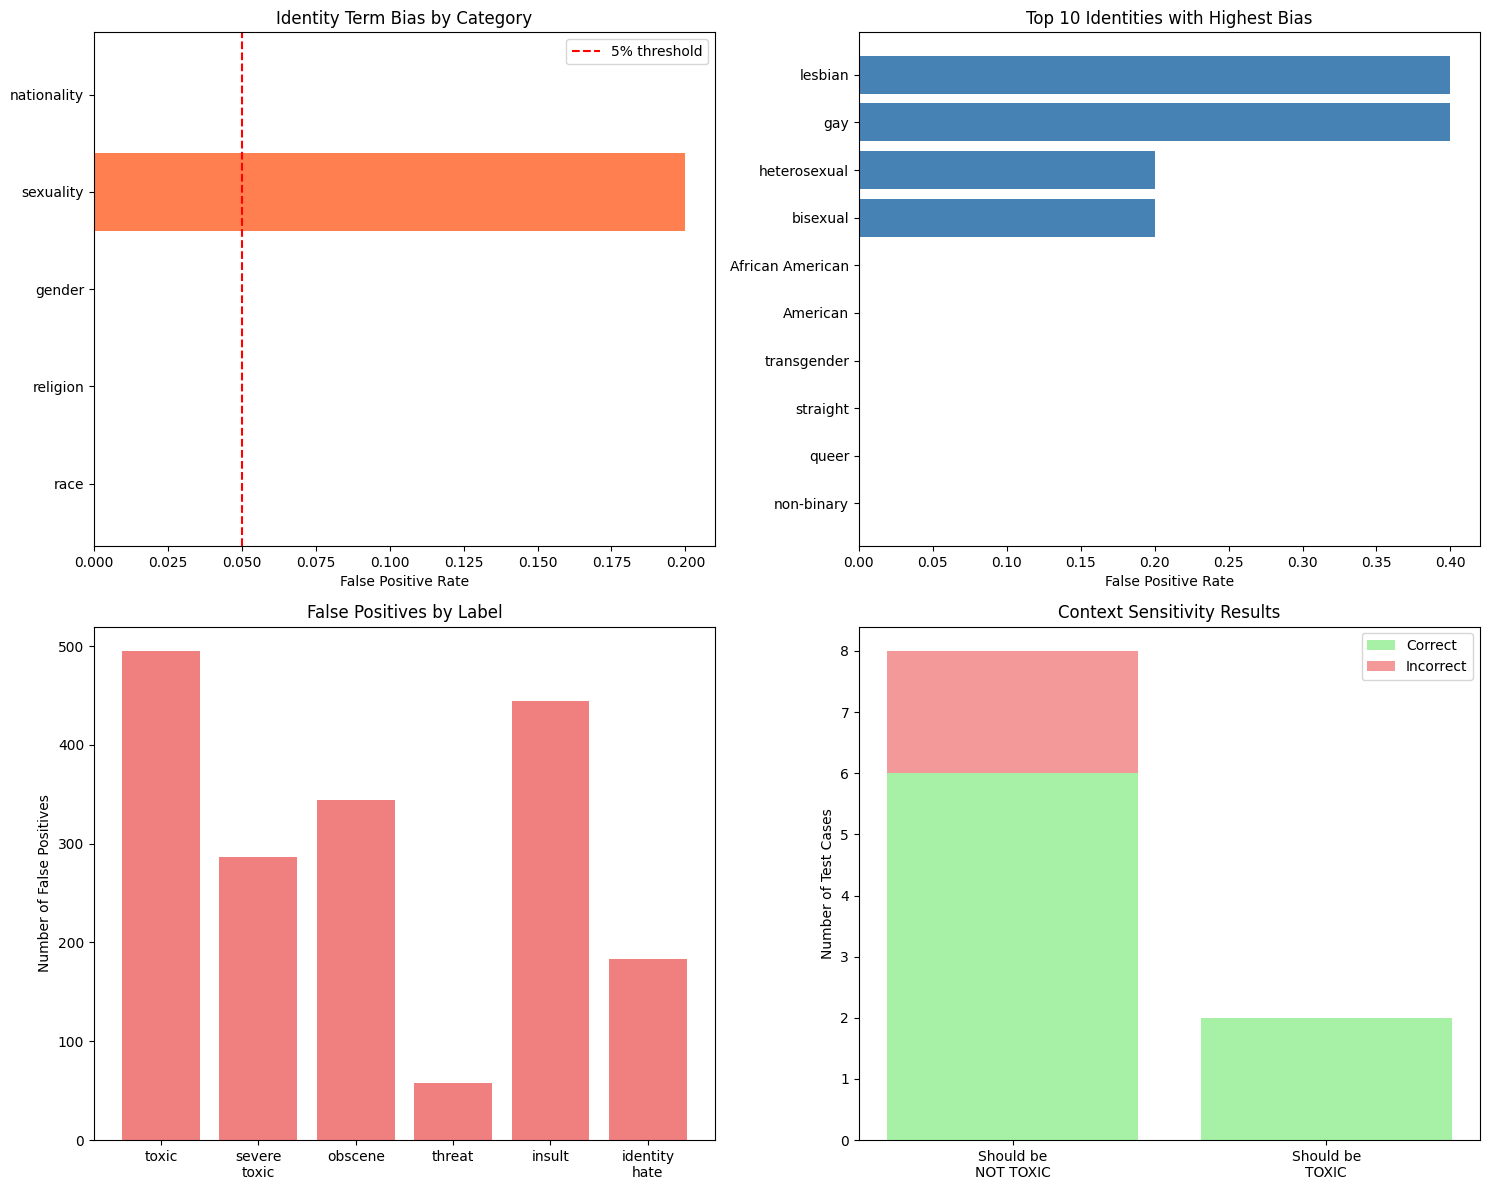


✅ BIAS TESTING COMPLETE!


In [8]:

# %%
# Cell 8 - Visualization

print("="*60)
print("Generating visualizations...")
print("="*60)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: False positive rate by identity category
ax1 = axes[0, 0]
cat_fp_rates = []
for category in identity_groups.keys():
    cat_df = bias_test_df[bias_test_df['category'] == category]
    cat_fp_rates.append(cat_df['flagged_as_toxic'].mean())

ax1.barh(list(identity_groups.keys()), cat_fp_rates, color='coral')
ax1.set_xlabel('False Positive Rate')
ax1.set_title('Identity Term Bias by Category')
ax1.axvline(x=0.05, color='red', linestyle='--', label='5% threshold')
ax1.legend()

# Plot 2: Top identities with highest bias
ax2 = axes[0, 1]
top_10 = identity_fp.head(10)
ax2.barh(range(len(top_10)), top_10['fp_rate'], color='steelblue')
ax2.set_yticks(range(len(top_10)))
ax2.set_yticklabels(top_10.index)
ax2.set_xlabel('False Positive Rate')
ax2.set_title('Top 10 Identities with Highest Bias')
ax2.invert_yaxis()

# Plot 3: False positive counts by label
ax3 = axes[1, 0]
fp_counts = [false_positives[label]['count'] for label in label_names]
ax3.bar(range(len(label_names)), fp_counts, color='lightcoral')
ax3.set_xticks(range(len(label_names)))
ax3.set_xticklabels([l.replace('_', '\n') for l in label_names], rotation=0)
ax3.set_ylabel('Number of False Positives')
ax3.set_title('False Positives by Label')

# Plot 4: Context sensitivity
ax4 = axes[1, 1]
context_results = context_df.groupby('expected')['correct'].agg(['sum', 'count'])
categories = ['Should be\nNOT TOXIC', 'Should be\nTOXIC']
correct_counts = [
    context_results.loc['NOT_TOXIC', 'sum'],
    context_results.loc['TOXIC', 'sum']
]
total_counts = [
    context_results.loc['NOT_TOXIC', 'count'],
    context_results.loc['TOXIC', 'count']
]

x = range(len(categories))
ax4.bar(x, correct_counts, label='Correct', color='lightgreen', alpha=0.8)
ax4.bar(x, [t - c for t, c in zip(total_counts, correct_counts)], 
        bottom=correct_counts, label='Incorrect', color='lightcoral', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.set_ylabel('Number of Test Cases')
ax4.set_title('Context Sensitivity Results')
ax4.legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "bias_testing_visualizations.png", dpi=300, bbox_inches='tight')
print(f"✅ Saved visualizations to: {ARTIFACT_DIR / 'bias_testing_visualizations.png'}")
plt.show()

print("\n" + "="*60)
print("✅ BIAS TESTING COMPLETE!")
print("="*60)